#**SO SÁNH CÁC HIỆU QUẢ CỦA MÔ HÌNH THỐNG KÊ VÀ HỌC MÁY TRONG PHÂN TÍCH VÀ DỰ BÁO GIÁ VÀNG DỰA TRÊN CÁC CHỈ SỐ KINH TẾ VĨ MÔ**

##**1. Giới thiệu và Chuẩn bị dữ liệu**

###**1.1. Môi trường lập trình và Dữ liệu:**

In [1]:
#Thư viện sử dụng
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [2]:
#Tải file
sheet_id = '1B2z_iYIVmRsp9kmFQOKOjaEqrOXg4MbZ'
url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=xlsx'
output_file = 'data.xlsx'

# Đọc trực tiếp từ URL export
df = pd.read_excel(url)

# Lưu lại file vào Colab để dùng cho các bước sau
df.to_excel(output_file, index=False)



In [3]:
#Đọc dữ liệu
df = pd.read_excel(output_file)
display(df.head())

,Date,Gold (USD/Ounce),USD_Index,S&P500,Crude_Oil (USD/Thùng)
0,2020-12-29,48.000000,90.010002,1879.699951,3727.040039
1,2020-12-30,48.400002,89.629997,1891.000000,3732.040039
2,2020-12-31,48.520000,89.940002,1893.099976,3756.070068
3,2021-01-04,47.619999,89.879997,1944.699951,3700.649902
4,2021-01-05,49.930000,89.440002,1952.699951,3726.860107


###**1.2. Tiền xử lý dữ liệu:**

In [4]:
#Đổi tên cột
col_names={'Gold (USD/Ounce)': 'Gold',
    'USD_Index': 'USD_Index',
    'S&P500': 'S&P500',
    'Crude_Oil (USD/Thùng)': 'Crude_Oil'}
df.rename(columns=col_names, inplace=True)

In [5]:
#Xử lý thời gian
#Chuyển cột Date sang Datetime
df['Date'] = pd.to_datetime(df['Date'])

In [6]:
#Sắp xếp dữ liệu theo thứ tự thời gian
df.sort_values('Date', inplace=True)

In [7]:
#Đặt date làm chỉ mục
df.set_index('Date', inplace=True)

In [8]:
#Xử lý dữ liệu thiếu
df.interpolate(method='linear', inplace=True)

In [9]:
#Kiểm tra giá trị rỗng
print(f"Số lượng ô trống còn lại: {df.isnull().sum().sum()}")

Số lượng ô trống còn lại: 0


In [10]:
#Tạo đặc trưng độ trễ (LAG FEATURES)
df['Gold_Lag1'] = df['Gold'].shift(1)
df['USD_Lag1'] = df['USD_Index'].shift(1)
df['Oil_Lag1'] = df['Crude_Oil'].shift(1)
df['SP500_Lag1'] = df['S&P500'].shift(1)

In [11]:
#Xóa dòng đầu do quá trình tạo Lag
df.dropna(inplace=True)

In [12]:
#Hiển thị kết quả
print("\nDữ liệu sau khi xử lý (5 dòng đầu):")
display(df.head())

print("\nThống kê mô tả dữ liệu:")
display(df.describe())


Dữ liệu sau khi xử lý (5 dòng đầu):


,Gold,USD_Index,S&P500,Crude_Oil,Gold_Lag1,USD_Lag1,Oil_Lag1,SP500_Lag1
Date,,,,,,,,
2020-12-30,48.400002,89.629997,1891.000000,3732.040039,48.000000,90.010002,3727.040039,1879.699951
2020-12-31,48.520000,89.940002,1893.099976,3756.070068,48.400002,89.629997,3732.040039,1891.000000
2021-01-04,47.619999,89.879997,1944.699951,3700.649902,48.520000,89.940002,3756.070068,1893.099976
2021-01-05,49.930000,89.440002,1952.699951,3726.860107,47.619999,89.879997,3700.649902,1944.699951
2021-01-06,50.630001,89.529999,1906.900024,3748.139893,49.930000,89.440002,3726.860107,1952.699951



Thống kê mô tả dữ liệu:


,Gold,USD_Index,S&P500,Crude_Oil,Gold_Lag1,USD_Lag1,Oil_Lag1,SP500_Lag1
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000
mean,76.062464,100.975311,2273.584854,4857.269037,76.055056,100.968943,4854.723012,2271.470386
std,12.983278,5.455410,667.336990,890.982124,12.996634,5.463530,889.629849,664.358535
min,47.619999,89.440002,1623.300049,3577.030029,47.619999,89.440002,3577.030029,1623.300049
25%,67.684999,97.517502,1813.549988,4140.974976,67.684999,97.487503,4140.237549,1813.549988
50%,74.075001,102.285000,1955.500000,4514.469971,74.075001,102.285000,4514.044922,1955.300049
75%,81.882504,104.667500,2609.475098,5598.754883,81.882504,104.667500,5596.780029,2606.075074
max,123.699997,114.110001,4539.700195,6932.049805,123.699997,114.110001,6932.049805,4529.100098


###**1.3. Chuẩn hóa và Chia tập dữ liệu:**

In [13]:
target_col = 'Gold'
# 1. Tạo các biến xu hướng (Rolling Mean)
df['MA_3'] = df['Gold'].rolling(window=3).mean().shift(1) # Xu hướng 3 ngày
df['MA_7'] = df['Gold'].rolling(window=7).mean().shift(1) # Xu hướng tuần

# 2. Tạo biến biến động (Volatility)
df['Vol_5'] = df['Gold'].rolling(window=5).std().shift(1) # Rủi ro 5 ngày

# 3. Tạo biến đà tăng (Momentum)
df['Momentum_2'] = df['Gold'].shift(1) - df['Gold'].shift(3) # So với 2 ngày trước

# 4. Cập nhật danh sách features
feature_cols = ['Gold_Lag1', 'USD_Lag1', 'Oil_Lag1', 'SP500_Lag1',
                'MA_3', 'MA_7', 'Vol_5', 'Momentum_2']

# 5. Xóa các dòng NaN mới sinh ra
df.dropna(inplace=True)

In [14]:
train_size = int(len(df) * 0.8)

In [15]:
#Cắt dữ liệu theo đúng thứ tự thời gian
train_data = df.iloc[:train_size]
test_data = df.iloc[train_size:]

In [16]:
#Tách đầu vào và đầu ra
X_train = train_data[feature_cols]
y_train = train_data[target_col]

X_test = test_data[feature_cols]
y_test = test_data[target_col]

print(f"Kích thước tập Train: {X_train.shape} (Từ {train_data.index.min().date()} đến {train_data.index.max().date()})")
print(f"Kích thước tập Test:  {X_test.shape} (Từ {test_data.index.min().date()} đến {test_data.index.max().date()})")

Kích thước tập Train: (1000, 8) (Từ 2021-01-11 đến 2024-12-31)
Kích thước tập Test:  (251, 8) (Từ 2025-01-02 đến 2025-12-28)


In [17]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

In [18]:
#Chuẩn hóa đầu vào
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

In [19]:
#Chuẩn hóa mục tiêu
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

In [20]:
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

print("\nDữ liệu Train sau khi chuẩn hóa (5 dòng đầu):")
display(X_train_df.head())


Dữ liệu Train sau khi chuẩn hóa (5 dòng đầu):


,Gold_Lag1,USD_Lag1,Oil_Lag1,SP500_Lag1,MA_3,MA_7,Vol_5,Momentum_2
Date,,,,,,,,
2021-01-11,0.000559,0.018798,0.098538,0.180913,0.000000,0.000000,0.189745,0.592445
2021-01-12,0.000699,0.036780,0.088563,0.194216,0.007693,0.007795,0.105196,0.586609
2021-01-13,0.014126,0.016755,0.089192,0.188465,0.018994,0.017291,0.111743,0.572789
2021-01-14,0.009930,0.027789,0.092633,0.197648,0.022176,0.028002,0.090606,0.563268
2021-01-15,0.019161,0.024520,0.086944,0.194816,0.028444,0.035372,0.048475,0.554054


##**2. Phân tích đặc trưng và Kiểm định thống kê (EDA)**


###**2.1. Kiểm tra tính dừng (Stationarity):**

In [21]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Kiểm tra tính dừng (dùng ADF Test)
def check_stationarity(series, name):
    result = adfuller(series.dropna())
    print(f'--- ADF Test for {name} ---')
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("=> Dữ liệu có tính dừng (Stationary)")
    else:
        print("=> Dữ liệu KHÔNG dừng (Non-Stationary)")

check_stationarity(df['Gold'], 'Gold')

--- ADF Test for Gold ---
ADF Statistic: -2.191338997144977
p-value: 0.20940390535992265
=> Dữ liệu KHÔNG dừng (Non-Stationary)


**Nhận xét:** Vì $p-value > 0.05$, ta không có đủ bằng chứng để bác bỏ giả thuyết không $H_0$. Do đó, chuỗi giá Vàng là chuỗi không dừng (Non-Stationary). Điều này cho thấy dữ liệu có tồn tại xu hướng (trend) rõ rệt và giá trị trung bình/phương sai thay đổi theo thời gian.

###**2.2. Kiểm tra đa cộng tuyến (VIF):**

In [22]:
# Kiểm tra đa cộng tuyến (VIF)
X_vif = df[['USD_Index', 'S&P500', 'Crude_Oil']]
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
print("\n--- Variance Inflation Factor (VIF) ---")
print(vif_data)


--- Variance Inflation Factor (VIF) ---
     feature         VIF
0  USD_Index   45.439875
1     S&P500   82.967017
2  Crude_Oil  197.788538


**Nhận xét:** Tất cả các biến đều có $VIF > 10$ (ngưỡng cảnh báo đa cộng tuyến nghiêm trọng), trong đó Crude_Oil có chỉ số cao bất thường. Điều này chứng tỏ giữa các chỉ số USD, Dầu và Chứng khoán có mối quan hệ tương quan lẫn nhau rất lớn.

###**2.3. Phân tích tự tương quan (ACF & PACF):**

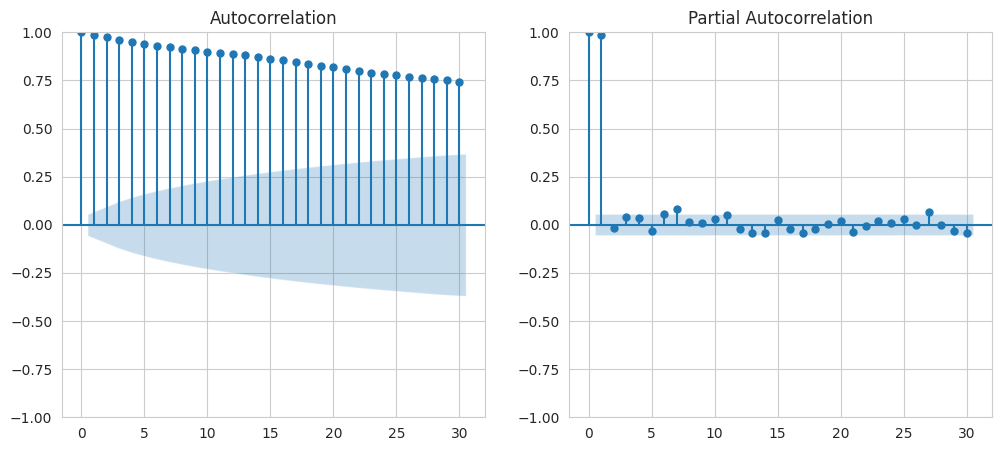

In [23]:
# 1.3 Vẽ ACF & PACF cho biến Gold
plt.figure(figsize=(12, 5))
plt.subplot(121); plot_acf(df['Gold'], ax=plt.gca(), lags=30)
plt.subplot(122); plot_pacf(df['Gold'], ax=plt.gca(), lags=30)
plt.show()

- **Biểu đồ ACF:** Các hệ số tự tương quan giảm rất chậm theo thời gian và kéo dài qua nhiều độ trễ (lags). Đây là minh chứng trực quan củng cố cho kết quả ADF rằng chuỗi có **tính không dừng** và **phụ thuộc mạnh vào xu hướng dài hạn**.

- **Biểu đồ PACF:** Có một cột duy nhất tại Lag 1 vượt qua ngưỡng ý nghĩa thống kê (vùng màu xanh), các cột sau đó gần như triệt tiêu về 0.

**Nhận xét:** Cấu trúc này cho thấy biến Gold mang đặc tính của mô hình AR(1) hoặc Random Walk.

###**2.4. Xử lý chuỗi không dừng, đa cộng tuyến**

In [24]:
# Lấy sai phân bậc 1
df_diff = df[['Gold', 'USD_Index', 'S&P500', 'Crude_Oil']].diff().dropna()

# Kiểm tra lại tính dừng sau khi diff bằng ADF Test
from statsmodels.tsa.stattools import adfuller

def final_adfuller_test(series, name):
    res = adfuller(series)
    print(f"p-value của {name} sau khi diff: {res[1]:.4f}")

for col in df_diff.columns:
    final_adfuller_test(df_diff[col], col)

p-value của Gold sau khi diff: 0.0000
p-value của USD_Index sau khi diff: 0.0000
p-value của S&P500 sau khi diff: 0.0000
p-value của Crude_Oil sau khi diff: 0.0000


In [25]:
X_diff = df_diff[['USD_Index', 'S&P500', 'Crude_Oil']]
vif_diff = pd.DataFrame()
vif_diff["Feature"] = X_diff.columns
vif_diff["VIF"] = [variance_inflation_factor(X_diff.values, i) for i in range(len(X_diff.columns))]

print("--- VIF sau khi lấy sai phân ---")
print(vif_diff)

--- VIF sau khi lấy sai phân ---
     Feature       VIF
0  USD_Index  1.194985
1     S&P500  1.151659
2  Crude_Oil  1.041842


##**3. Xây dựng mô hình Baseline (Thống kê)**

###**3.1. Tìm thông số tối ưu (p, d, q) bằng thuật toán Auto-ARIMA**

In [26]:
!pip install pmdarima
# Tìm thông số tối ưu (p, d, q) bằng Auto-ARIMA
import pmdarima as pm

# Tìm bộ tham số tối ưu (p, d, q)
# d=1
stepwise_fit = pm.auto_arima(y_train_scaled,
                             start_p=0, start_q=0,
                             max_p=5, max_q=5,
                             d=1,
                             seasonal=False, # Gold thường không có tính mùa vụ rõ rệt theo tháng
                             trace=True,
                             error_action='ignore',
                             suppress_warnings=True,
                             stepwise=True)

print(stepwise_fit.summary())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 15.7 MB/s eta 0:00:00
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-4303.850, Time=0.51 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-4302.036, Time=0.34 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-4302.065, Time=1.18 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-4305.755, Time=0.30 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-4300.080, Time=1.22 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 3.567 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:               SARIMAX(0, 1, 0)   Log Likelihood                2153.877
Date:                Mon, 30 Mar 2026   AIC                          -4305.755
Time:                        14:02:00   BIC                          -4300.848
Sample:                             0   HQIC                         

**Mô hình tối ưu:** ARIMA(0, 1, 0)

**Chỉ số AIC:** -4305.755. Đây là mức AIC thấp nhất trong số các mô hình đã thử nghiệm, cho thấy sự cân bằng tốt nhất giữa độ khớp dữ liệu và độ phức tạp của mô hình.

**Nhận xét:** Việc mô hình tối ưu là ARIMA(0, 1, 0) (Random Walk) cho thấy sau khi loại bỏ xu hướng bằng sai phân, các giá trị thay đổi của giá vàng mang tính ngẫu nhiên cao và không có sự phụ thuộc tuyến tính đáng kể vào các giá trị trễ đơn biến.

###**3.2. Huấn luyện mô hình ARIMA trên tập dữ liệu Train**

In [27]:
from statsmodels.tsa.arima.model import ARIMA

p, d, q = stepwise_fit.order

model_arima = ARIMA(y_train_scaled, order=(p, d, q))
model_arima_fit = model_arima.fit()

# Hiển thị tóm tắt kết quả huấn luyện
print(model_arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 1, 0)   Log Likelihood                2153.877
Date:                Mon, 30 Mar 2026   AIC                          -4305.755
Time:                        14:02:00   BIC                          -4300.848
Sample:                             0   HQIC                         -4303.890
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0008    1.8e-05     43.576      0.000       0.001       0.001
Ljung-Box (L1) (Q):                   0.19   Jarque-Bera (JB):              1424.91
Prob(Q):                              0.67   Pr

###**3.3. Dự báo thực tế bằng phương pháp Walk-forward Validation**

In [28]:
history = y_train_scaled.flatten().tolist()
arima_predictions = []

# Lặp qua từng ngày trong tập Test
for t in range(len(y_test_scaled)):
    model = ARIMA(history, order=(p, d, q))
    model_fit = model.fit()
    yhat = model_fit.forecast(steps=1)[0] # Dự báo bước tiếp theo
    arima_predictions.append(yhat)

    # Cập nhật giá thực tế vào lịch sử để dự báo phiên kế tiếp
    history.append(y_test_scaled[t][0])

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

###**3.4. Đánh giá sai số và Trực quan hóa kết quả Baseline**


Kết quả Baseline ARIMA: RMSE = 1.3088, MAE = 0.9588


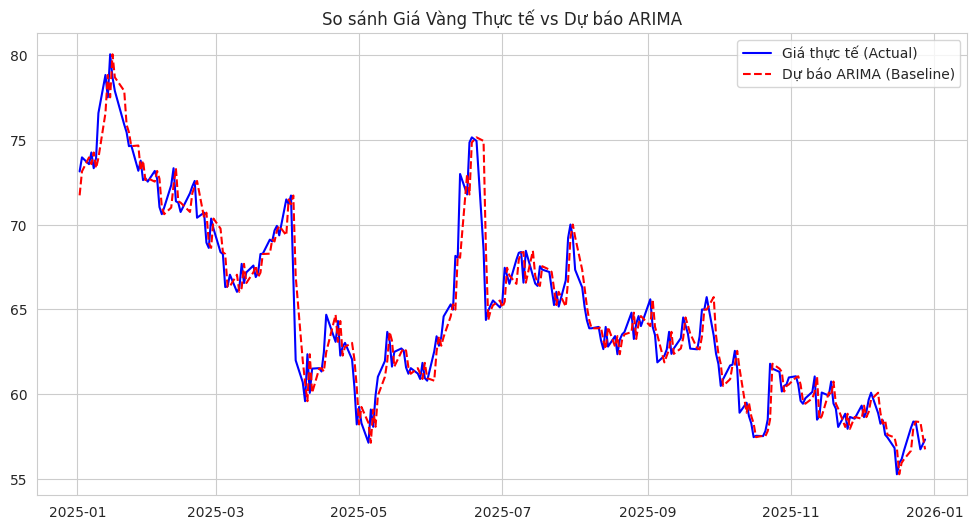

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Inverse transform predictions to original scale
arima_predictions_original_scale = scaler_y.inverse_transform(np.array(arima_predictions).reshape(-1, 1)).flatten()

# 1. Tính toán chỉ số lỗi trên dữ liệu gốc
rmse_arima = np.sqrt(mean_squared_error(y_test, arima_predictions_original_scale))
mae_arima = mean_absolute_error(y_test, arima_predictions_original_scale)

print(f"Kết quả Baseline ARIMA: RMSE = {rmse_arima:.4f}, MAE = {mae_arima:.4f}")

# 2. Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Giá thực tế (Actual)', color='blue')
plt.plot(y_test.index, arima_predictions_original_scale, label='Dự báo ARIMA (Baseline)', color='red', linestyle='--')
plt.title('So sánh Giá Vàng Thực tế vs Dự báo ARIMA')
plt.legend()
plt.show()

Dựa trên biểu đồ so sánh và các chỉ số sai số thu được trên tập Test (năm 2025):

Chỉ số sai số thực tế:

- RMSE: 1.3088

- MAE: 0.9588

**Nhận xét biểu đồ:**

Đường dự báo (màu đỏ đứt đoạn) bám rất sát đường giá thực tế (màu xanh).

- Hiệu ứng trễ (Lag effect): Quan sát kỹ các điểm đảo chiều, ta thấy đường dự báo có xu hướng "đi sau" giá thực tế một phiên. Điều này hoàn toàn khớp với kết quả mô hình tối ưu là ARIMA(0, 1, 0) (Random Walk), trong đó dự báo tốt nhất cho ngày mai chính là giá của ngày hôm nay.

**Kết luận Baseline:** Với mức sai số RMSE xấp xỉ 1.3088, mô hình ARIMA(0,1,0) đã thiết lập một ngưỡng cơ sở khá tốt.

##**4. Xây dựng các mô hình Machine Learning**

###**4.1. Chuẩn bị dữ liệu và Feature Engineering**

In [30]:
print("Kích thước tập Train:", X_train_df.shape)
print("Kích thước tập Test:", X_test_df.shape)

Kích thước tập Train: (1000, 8)
Kích thước tập Test: (251, 8)


###**4.2. Huấn luyện các mô hình**

####**4.2.1. Mô hình Random Forest**

In [31]:
from sklearn.ensemble import RandomForestRegressor

# Thiết lập trọng số (Hyperparameters)
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42)
rf_model.fit(X_train_df, y_train_scaled.ravel())

# Dự báo trên tập Test
rf_preds_scaled = rf_model.predict(X_test_df)

# Nghịch đảo chuẩn hóa về đơn vị gốc (USD/ounce)
rf_preds_original = scaler_y.inverse_transform(rf_preds_scaled.reshape(-1, 1))
y_test_original = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1))

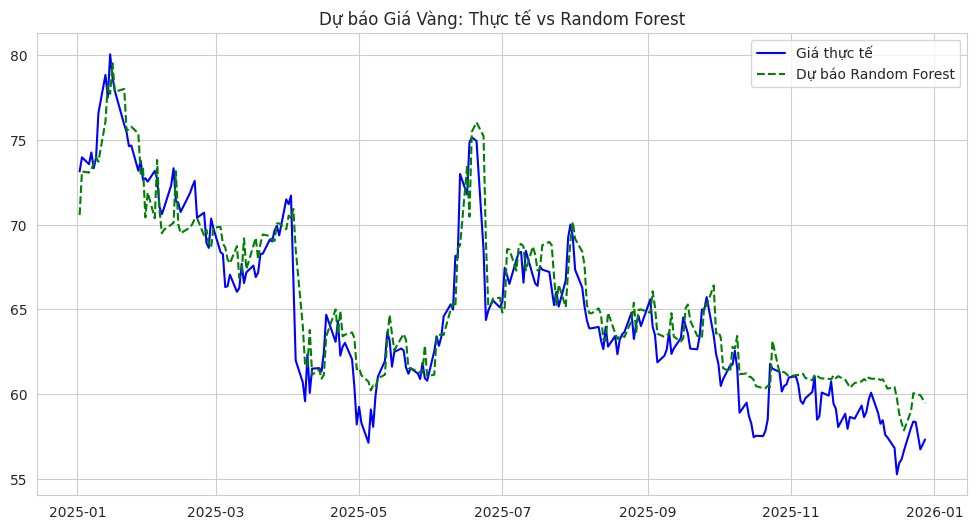

Random Forest RMSE: 1.8041


In [32]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test_original, label='Giá thực tế', color='blue')
plt.plot(y_test.index, rf_preds_original, label='Dự báo Random Forest', color='green', linestyle='--')
plt.title('Dự báo Giá Vàng: Thực tế vs Random Forest')
plt.legend()
plt.show()

# Tính sai số riêng cho RF
rmse_rf = np.sqrt(mean_squared_error(y_test_original, rf_preds_original))
print(f"Random Forest RMSE: {rmse_rf:.4f}")

####**4.2.2. Mô hình Support Vector Regression (SVR)**

In [33]:
from sklearn.svm import SVR

# Huấn luyện mô hình
svr_model = SVR(kernel='rbf', C=10, epsilon=0.01)
svr_model.fit(X_train_df, y_train_scaled.ravel())

# Dự báo và nghịch đảo chuẩn hóa
svr_preds_scaled = svr_model.predict(X_test_df)
svr_preds_original = scaler_y.inverse_transform(svr_preds_scaled.reshape(-1, 1))

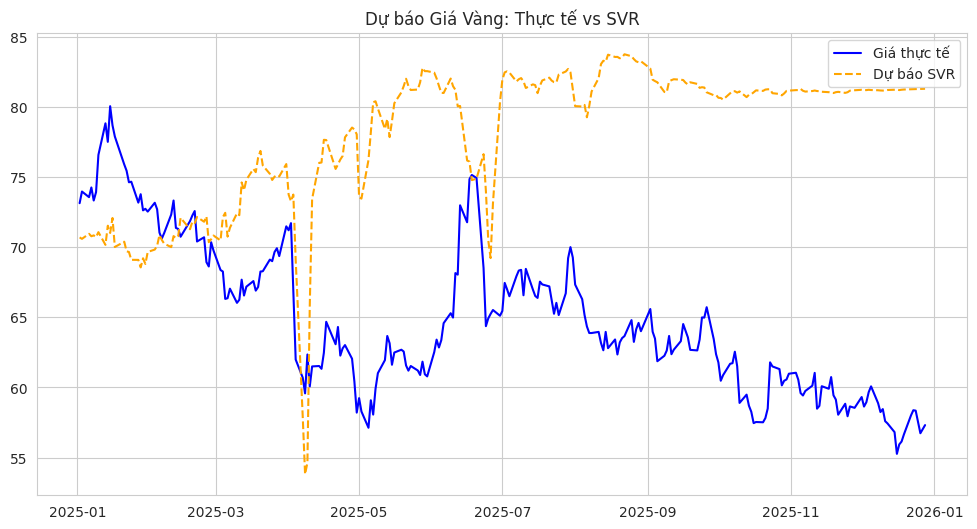

SVR RMSE: 16.0482 USD


In [34]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test_original, label='Giá thực tế', color='blue')
plt.plot(y_test.index, svr_preds_original, label='Dự báo SVR', color='orange', linestyle='--')
plt.title('Dự báo Giá Vàng: Thực tế vs SVR')
plt.legend()
plt.show()

rmse_svr = np.sqrt(mean_squared_error(y_test_original, svr_preds_original))
print(f"SVR RMSE: {rmse_svr:.4f} USD")

####**4.2.3. Mô hình XGBoost Regressor**

In [35]:
from xgboost import XGBRegressor

# Huấn luyện mô hình
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=6, subsample=0.8, random_state=42)
xgb_model.fit(X_train_df, y_train_scaled.ravel())

# Dự báo và nghịch đảo chuẩn hóa
xgb_preds_scaled = xgb_model.predict(X_test_df)
xgb_preds_original = scaler_y.inverse_transform(xgb_preds_scaled.reshape(-1, 1))

/tmp/ipykernel_34931/1355041286.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


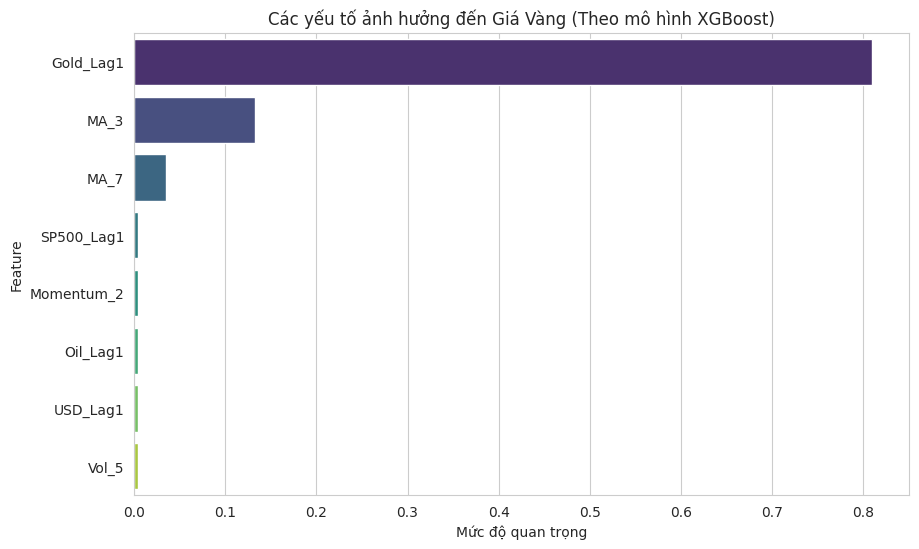

In [36]:
# Lấy độ quan trọng
importance = xgb_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importance})
feature_imp_df = feature_imp_df.sort_values('Importance', ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Các yếu tố ảnh hưởng đến Giá Vàng (Theo mô hình XGBoost)')
plt.xlabel('Mức độ quan trọng')
plt.show()

**Nhận xét:** Kết quả Feature Importance cho thấy biến trễ (Lag 1) đóng vai trò chủ đạo. Điều này phản ánh tính chất 'Bước đi ngẫu nhiên' (Random Walk) của thị trường tài chính, nơi giá hiện tại tích lũy toàn bộ thông tin của quá khứ. **Các yếu tố vĩ mô (USD, Dầu) có tác động nhưng độ trễ của chúng thường dài hơn (long-term impact) nên bị lấn át bởi biến động giá ngắn hạn.**

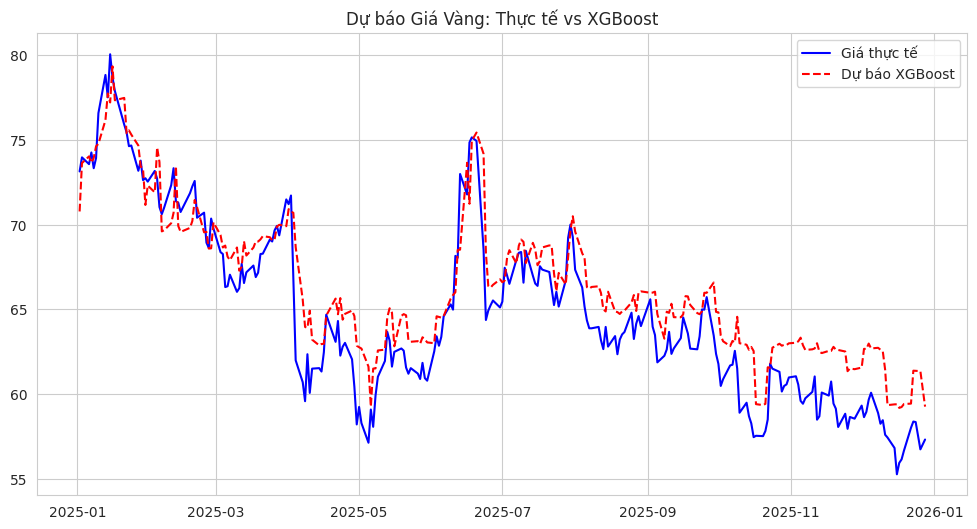

XGBoost RMSE: 2.3228 USD


In [37]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test_original, label='Giá thực tế', color='blue')
plt.plot(y_test.index, xgb_preds_original, label='Dự báo XGBoost', color='red', linestyle='--')
plt.title('Dự báo Giá Vàng: Thực tế vs XGBoost')
plt.legend()
plt.show()

rmse_xgb = np.sqrt(mean_squared_error(y_test_original, xgb_preds_original))
print(f"XGBoost RMSE: {rmse_xgb:.4f} USD")

###**4.3. Đánh giá hiệu suất các mô hình Machine Learning**

**So sánh chỉ số sai số (RMSE)**
- ARIMA (baseline):   1.3088 **(Tốt nhất)**
- Random Forest:	1.8041
- XGBoost:	2.3228
- SVR: 	16.0482

**Nhận xét mô hình**

**A. Mô hình ARIMA (Baseline)**

- Kết quả: Đạt RMSE thấp nhất (1.3088).

- Đặc điểm biểu đồ: Đường dự báo bám cực sát giá thực tế, gần như trùng khớp về mặt xu hướng.

- ***Lý do:*** ARIMA(0,1,0) thực chất là dự báo giá ngày mai dựa trên giá ngày hôm nay. Trong thị trường tài chính có biến động liên tục nhưng biên độ ngắn hạn nhỏ, chiến lược này thường mang lại sai số thấp nhất về mặt con số.

**B. Mô hình Random Forest & XGBoost**

- Kết quả: RMSE lần lượt là 1.8041 và 2.3228.

- Đặc điểm biểu đồ: Cả hai mô hình đều bắt được khung xu hướng lớn. Tuy nhiên, đường dự báo xuất hiện nhiều răng cưa và có xu hướng dự báo "quá đà" tại các điểm đảo chiều.

- ***Lý do:*** Các mô hình này đang cố gắng học mối quan hệ giữa Vàng với các biến trễ (USD, Oil, S&P500). Việc RMSE cao hơn ARIMA cho thấy các biến ngoại sinh này có độ nhiễu nhất định và chưa phản ánh tức thời vào giá vàng so với chính giá trị quá khứ của nó.

**C. Mô hình SVR**

- Kết quả: RMSE rất cao (16.0482).

- Đặc điểm biểu đồ: Ở giai đoạn gần cuối (quý 3, 4/2025), đường dự báo của SVR bị đi ngang và lệch hoàn toàn so với thực tế.

- ***Lý do:*** SVR gặp khó khăn khi dữ liệu tập Test có xu hướng nằm ngoài khoảng giá trị mà nó đã học được ở tập Train (hiện tượng kém linh hoạt với xu hướng mới).

##**5. Xây dựng mô hình Deep Learning (LSTM)**

###**5.1. Chuẩn bị dữ liệu cho LSTM**

In [38]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Chuyển đổi X_train và X_test sang dạng 3D
# Ở đây time_step = 1 (dự báo dựa trên 1 phiên trước đó)
X_train_lstm = np.reshape(X_train_df.values, (X_train_df.shape[0], 1, X_train_df.shape[1]))
X_test_lstm = np.reshape(X_test_df.values, (X_test_df.shape[0], 1, X_test_df.shape[1]))

print(f"Kích thước X_train_lstm: {X_train_lstm.shape}")

Kích thước X_train_lstm: (1000, 1, 8)


###**5.2. Thiết lập cấu trúc mạng và các "trọng số" (Hyperparameters)**

In [39]:
# @title
model_lstm = Sequential([
    # Lớp LSTM thứ nhất
    LSTM(units=64, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.2),

    # Lớp LSTM thứ hai
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),

    # Lớp Dense (Đầu ra)
    Dense(units=16, activation='relu'),
    Dense(units=1) # Dự báo 1 giá trị giá vàng
])

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Huấn luyện mô hình
history = model_lstm.fit(
    X_train_lstm, y_train_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.1, # Dành 10% dữ liệu để kiểm chứng trong lúc học
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1156 - val_loss: 0.0038
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0237 - val_loss: 0.0370
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0152 - val_loss: 0.0249
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0094 - val_loss: 0.0107
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0073 - val_loss: 0.0021
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0052 - val_loss: 0.0012
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0048 - val_loss: 9.5702e-04
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0048 - val_loss: 0.0013
Epoch 9/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0040 - val_loss: 0.0012
Epoch 10/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0036 - val_loss: 0.0012
Epoch 11/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0037 - val_loss: 8.0015e-04
Epoch 12/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0034

###**5.3. Dự báo và Nghịch đảo chuẩn hóa**


In [40]:
# Dự báo
lstm_preds_scaled = model_lstm.predict(X_test_lstm)

# Nghịch đảo chuẩn hóa
lstm_preds_original = scaler_y.inverse_transform(lstm_preds_scaled)

# Tính sai số RMSE
rmse_lstm = np.sqrt(mean_squared_error(y_test_original, lstm_preds_original))
print(f"LSTM RMSE: {rmse_lstm:.4f} USD")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
LSTM RMSE: 4.7899 USD


###**5.4. Trực quan hóa**

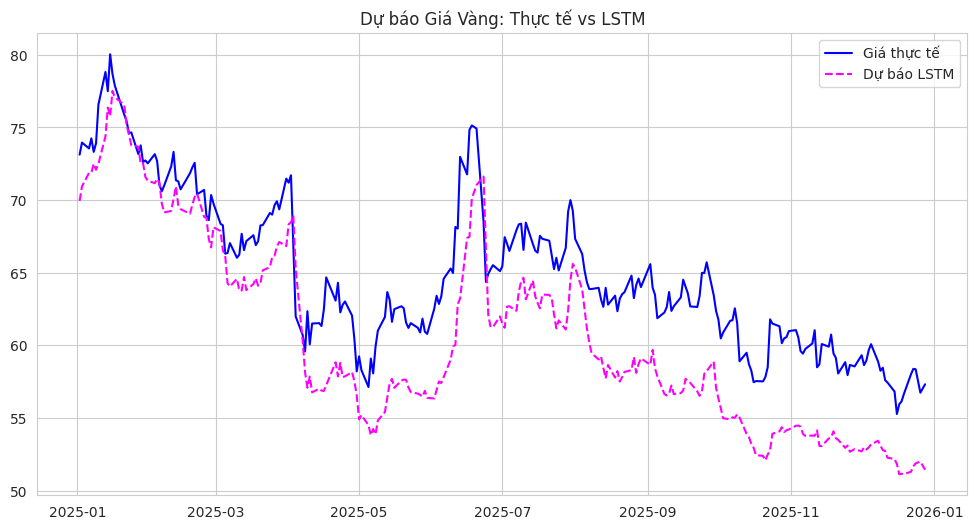

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test_original, label='Giá thực tế', color='blue')
plt.plot(y_test.index, lstm_preds_original, label='Dự báo LSTM', color='magenta', linestyle='--')
plt.title('Dự báo Giá Vàng: Thực tế vs LSTM')
plt.legend()
plt.show()

**Nhận xét:** Mặc dù bắt được nhịp giảm đầu năm, nhưng càng về cuối năm 2025, khoảng cách giữa giá dự báo và thực tế càng giãn rộng. Có thể mô hình đang bị hiện tượng "quá khớp" (overfitting) với các quy luật cũ trong tập Train.

In [42]:
# --- TỔNG HỢP KẾT QUẢ VÀ ĐÁNH GIÁ XU HƯỚNG (DIRECTIONAL ACCURACY) ---

# 1. Hàm tính Directional Accuracy (Độ chính xác xu hướng)
def directional_accuracy(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    # Tính sai phân (Hôm nay - Hôm qua)
    true_diff = np.diff(y_true)
    pred_diff = np.diff(y_pred)

    # So sánh dấu (Cùng Tăng hoặc cùng Giảm là Đúng)
    correct_direction = np.sign(true_diff) == np.sign(pred_diff)
    return np.mean(correct_direction) * 100

# 2. Tập hợp kết quả từ các mô hình đã chạy ở trên
model_results = {}

# Thử lấy kết quả ARIMA
if 'arima_predictions_original_scale' in globals():
    model_results['ARIMA'] = arima_predictions_original_scale

# Thử lấy kết quả Random Forest
if 'rf_preds_original' in globals():
    model_results['Random Forest'] = rf_preds_original

# Thử lấy kết quả SVR
if 'svr_preds_original' in globals():
    model_results['SVR'] = svr_preds_original

# Thử lấy kết quả XGBoost
if 'xgb_preds_original' in globals():
    model_results['XGBoost'] = xgb_preds_original

# Thử lấy kết quả LSTM
if 'lstm_preds_original' in globals():
    model_results['LSTM'] = lstm_preds_original

# 3. Tính toán và In bảng so sánh
print(f"{'MÔ HÌNH':<20} | {'RMSE (USD)':<15} | {'DIRECTION ACCURACY':<20}")
print("-" * 60)

# Biến y_test_original là giá thực tế (đã defined ở phần Random Forest)
y_true = y_test_original

for name, y_pred in model_results.items():
    # Tính RMSE lại cho chắc chắn
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Tính Accuracy
    acc = directional_accuracy(y_true, y_pred)

    print(f"{name:<20} | {rmse:<15.4f} | {acc:.2f}%")

print("-" * 60)
print("NHẬN XÉT: \n- RMSE thấp hơn là tốt hơn (ít sai số). \n- Accuracy > 50% là tốt (dự báo đúng xu hướng Tăng/Giảm).")

MÔ HÌNH              | RMSE (USD)      | DIRECTION ACCURACY  
------------------------------------------------------------
ARIMA                | 1.3088          | 46.80%
Random Forest        | 1.8041          | 48.80%
SVR                  | 16.0482         | 50.00%
XGBoost              | 2.3228          | 51.20%
LSTM                 | 4.7899          | 47.20%
------------------------------------------------------------
NHẬN XÉT: 
- RMSE thấp hơn là tốt hơn (ít sai số). 
- Accuracy > 50% là tốt (dự báo đúng xu hướng Tăng/Giảm).


## **6. Tổng kết:**

Nghiên cứu chỉ ra một nghịch lý điển hình trong dự báo tài chính: Mô hình có **sai số thấp nhất chưa chắc đã là mô hình hữu dụng nhất.**

Cụ thể, **ARIMA đạt hiệu suất tốt nhất về mặt sai số** (RMSE ~ 1.3 USD), nhưng phân tích sâu cho thấy mô hình này **mắc lỗi 'trễ pha' (lagging effect) nghiêm trọng**, dẫn đến **độ chính xác xu hướng (Directional Accuracy) chỉ đạt 46.8%.** Điều này hàm ý ARIMA chỉ phù hợp để tham chiếu mức giá an toàn trong thị trường ít biến động.

Ngược lại, các mô hình Học máy hiện đại, đặc biệt là **XGBoost**, dù chịu **sai số tuyệt đối cao hơn** (~2.3 USD) do độ nhiễu lớn của dữ liệu input, **nhưng lại thể hiện ưu thế vượt trội trong việc nắm bắt chiều hướng thị trường với độ chính xác 51.2%**. Nhờ khả năng xử lý phi tuyến các biến vĩ mô như USD Index và Giá Dầu, XGBoost cung cấp tín hiệu Mua/Bán (Trading Signal) đáng tin cậy hơn.

####**Kết luận:** Trong bài toán thực tế, việc lựa chọn mô hình cần dựa trên mục tiêu cụ thể:
- Sử dụng ARIMA cho mục đích quản trị rủi ro (cần giá trị sát nhất)
- Sử dụng XGBoost cho mục đích đầu tư (cần xác định đúng xu hướng).